In [1]:
import numpy as np 
from pathlib import Path
from src import utils, behavmatch, db
import matplotlib.pyplot as plt
from scipy.stats import sem
import seaborn as sns
%matplotlib inline
%load_ext autoreload
%autoreload 2
from matplotlib import rcParams
default_font = 15
fs_title = 16
rcParams["font.family"] = "Arial"
rcParams["savefig.dpi"] = 300
rcParams["axes.spines.top"] = False
rcParams["axes.spines.right"] = False
rcParams["axes.titlelocation"] = "left"
rcParams["axes.titleweight"] = "normal"
rcParams["font.size"] = default_font
trial_type_palette = ['tab:green', 'tab:red', 'tab:cyan', 'tab:orange'] #rew #nrew #rew_test #nrew_test #GI
from IPython.display import clear_output

In [2]:
def plot_catvsbehav(behav_cov_catA, behav_cov_catB, ylabel, xlabel, ax, legend=False):
    cat_a = behav_cov_catA
    cat_b = behav_cov_catB
    ax.plot(cat_a.mean(0), color='tab:green', linestyle='-', label='Category A')
    ax.fill_between(np.arange(400), cat_a.mean(0)-sem(cat_a, axis=0), cat_a.mean(0)+sem(cat_a, axis=0), alpha=0.3, color='tab:green')
    ax.plot(cat_b.mean(0), color='tab:red', linestyle='-', label='Category B')
    ax.fill_between(np.arange(400), cat_b.mean(0)-sem(cat_b, axis=0), cat_b.mean(0)+sem(cat_b, axis=0), alpha=0.3, color='tab:red')
    ax.set_ylabel(ylabel)
    ax.set_xticks([0, 150, 250, 300, 400], ['0', '150', '250', '300', '400'], rotation=45)    
    if legend:
        ax.legend(bbox_to_anchor=(1.05, .9), fontsize=default_font, frameon=False)
    if xlabel:
        ax.set_xlabel("Position (cm)")
    #fill between 0 and 100 with gray
    ymin, ymax = ax.get_ylim()
    ax.fill_between(np.arange(100), ymin, ymax, color='gray', alpha=0.2)
    ax.axvline(150, color='k', linestyle='--', alpha=0.3)
    ax.axvline(250, color='k', linestyle='--', alpha=0.3)
    ax.axvline(300, color='k', linestyle='--', alpha=0.3)

In [3]:
from src import db
behav_sess = db.get_sessions().query("session == 'last training' & recording == True &  obj == 'old'").reset_index(drop=True)

In [3]:
obj_path = Path(r"D:\mouseobj")

In [5]:
matched_feature_means = np.zeros((len(behav_sess), 5, 2, 400)) # mice, features, cat, positions
nonmatched_feature_means = np.zeros((len(behav_sess), 5, 2, 400)) # mice, features, cat, positions
for im, sess in behav_sess.iterrows():
    name, date, blk = sess['mname'], sess['datexp'], sess['blk']
    m = utils.load_mouse(name, date, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj") 
    speed, lick_rate, delta_motion, delta_pupil = behavmatch.load_behav_data(m)
    save_pth = obj_path.joinpath(name,date,blk)
    probs = np.load(obj_path.joinpath(name,date,blk,"probs.npy"), allow_pickle=True)
    np.save(save_pth.joinpath("speed_interp.npy"), speed)
    np.save(save_pth.joinpath("lick_rate.npy"), lick_rate)
    np.save(save_pth.joinpath("motion_energy_corridor.npy"), delta_motion)
    np.save(save_pth.joinpath("pupil_area_corridor.npy"), delta_pupil)
    acc = behavmatch.compute_acceleration(speed, ew=.2)
    features = [lick_rate, speed, acc, delta_pupil, delta_motion]
    feature_means = np.zeros((len(features), 2, 400))
    neurons, trials, positions = m.interp_spks.shape
    protA = m.trial_dict["rewarded"][1::2]
    protB = m.trial_dict["non rewarded"][1::2]
    restA = m.trial_dict["rewarded test"]
    restB =  m.trial_dict["non rewarded test"]
    prot_matched_trials = behavmatch.match_trials_by_prob_bins(probs, 3, protA, protB, bins=np.linspace(0, 1, 11), random_state=0)
    rest_matched_trials = behavmatch.match_trials_by_prob_bins(probs, 3, restA, restB, bins=np.linspace(0, 1, 11), random_state=0)
    catA_prot = np.concatenate(prot_matched_trials[:,0]).astype(int)
    catB_prot = np.concatenate(prot_matched_trials[:,1]).astype(int)
    catA_rest = np.concatenate(rest_matched_trials[:,0]).astype(int)
    catB_rest = np.concatenate(rest_matched_trials[:,1]).astype(int)
    catA_matched = np.concatenate([catA_prot, catA_rest])
    catB_matched = np.concatenate([catB_prot, catB_rest])
    catA_nonmatched = np.concatenate([m.trial_dict["rewarded"], m.trial_dict["rewarded test"]])
    catB_nonmatched = np.concatenate([m.trial_dict["non rewarded"], m.trial_dict["non rewarded test"]])
    for i_f, feature in enumerate(features):
        matched_feature_means[im, i_f, 0] = feature[catA_matched].mean(0)
        matched_feature_means[im, i_f, 1] = feature[catB_matched].mean(0)
        nonmatched_feature_means[im, i_f, 0] = feature[catA_nonmatched].mean(0)
        nonmatched_feature_means[im, i_f, 1] = feature[catB_nonmatched].mean(0)

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_10_31\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_14\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG14\2024_11_21\2
Existing mouse object has the following attr

In [ ]:
save_path = obj_path.joinpath("overall", "last_training")
np.save(save_path.joinpath("matched_feature_means.npy"), matched_feature_means)
np.save(save_path.joinpath("nonmatched_feature_means.npy"), nonmatched_feature_means)

In [4]:
from src import db
behav_sess = db.get_sessions().query("session == 'last training' & recording == True &  obj == 'new'").reset_index(drop=True)

In [29]:
matched_feature_means = np.zeros((len(behav_sess), 5, 2, 400)) # mice, features, cat, positions
nonmatched_feature_means = np.zeros((len(behav_sess), 5, 2, 400)) # mice, features, cat, positions
for im, sess in behav_sess.iterrows():
    name, date, blk = sess['mname'], sess['datexp'], sess['blk']
    m = utils.load_mouse(name, date, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj") 
    speed, lick_rate, delta_motion, delta_pupil = behavmatch.load_behav_data(m)
    save_pth = obj_path.joinpath(name,date,blk)
    probs = np.load(obj_path.joinpath(name,date,blk,"probs.npy"), allow_pickle=True)
    np.save(save_pth.joinpath("speed_interp.npy"), speed/10)
    np.save(save_pth.joinpath("lick_rate.npy"), lick_rate)
    np.save(save_pth.joinpath("motion_energy_corridor.npy"), delta_motion)
    np.save(save_pth.joinpath("pupil_area_corridor.npy"), delta_pupil)
    acc = behavmatch.compute_acceleration(speed, ew=.2)
    features = [lick_rate, speed/10, acc, delta_pupil, delta_motion]
    feature_means = np.zeros((len(features), 2, 400))
    neurons, trials, positions = m.interp_spks.shape
    protA = m.trial_dict["rewarded"][1::2]
    protB = m.trial_dict["non rewarded"][1::2]
    restA = m.trial_dict["rewarded test"]
    restB =  m.trial_dict["non rewarded test"]
    prot_matched_trials = behavmatch.match_trials_by_prob_bins(probs, 3, protA, protB, bins=np.linspace(0, 1, 11), random_state=0)
    rest_matched_trials = behavmatch.match_trials_by_prob_bins(probs, 3, restA, restB, bins=np.linspace(0, 1, 11), random_state=0)
    catA_prot = np.concatenate(prot_matched_trials[:,0]).astype(int)
    catB_prot = np.concatenate(prot_matched_trials[:,1]).astype(int)
    catA_rest = np.concatenate(rest_matched_trials[:,0]).astype(int)
    catB_rest = np.concatenate(rest_matched_trials[:,1]).astype(int)
    catA_matched = np.concatenate([catA_prot, catA_rest])
    catB_matched = np.concatenate([catB_prot, catB_rest])
    catA_nonmatched = np.concatenate([m.trial_dict["rewarded"], m.trial_dict["rewarded test"]])
    catB_nonmatched = np.concatenate([m.trial_dict["non rewarded"], m.trial_dict["non rewarded test"]])
    for i_f, feature in enumerate(features):
        matched_feature_means[im, i_f, 0] = feature[catA_matched].mean(0)
        matched_feature_means[im, i_f, 1] = feature[catB_matched].mean(0)
        nonmatched_feature_means[im, i_f, 0] = feature[catA_nonmatched].mean(0)
        nonmatched_feature_means[im, i_f, 1] = feature[catB_nonmatched].mean(0)

Checking if model object exists ...
Loading mouse object from D:\mouseobj\VGa9\2025_11_20\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])


In [19]:
save_path = obj_path.joinpath("overall", "last_training")
matched_feature_means_old = np.load(save_path.joinpath("matched_feature_means.npy"))
nonmatched_feature_means_old = np.load(save_path.joinpath("nonmatched_feature_means.npy"))

In [9]:
vstacked_matched = np.vstack([matched_feature_means_old, matched_feature_means])
vstacked_nonmatched = np.vstack([nonmatched_feature_means_old, nonmatched_feature_means])
vstacked_matched.shape, vstacked_nonmatched.shape

((10, 5, 2, 400), (10, 5, 2, 400))

In [31]:
save_path = obj_path.joinpath("overall", "last_training")
np.save(save_path.joinpath("matched_feature_means.npy"), vstacked_matched )
np.save(save_path.joinpath("nonmatched_feature_means.npy"), vstacked_nonmatched)

In [34]:
vstack_matched = np.load(save_path.joinpath("matched_feature_means.npy"))
vstack_nonmatched = np.load(save_path.joinpath("nonmatched_feature_means.npy"))

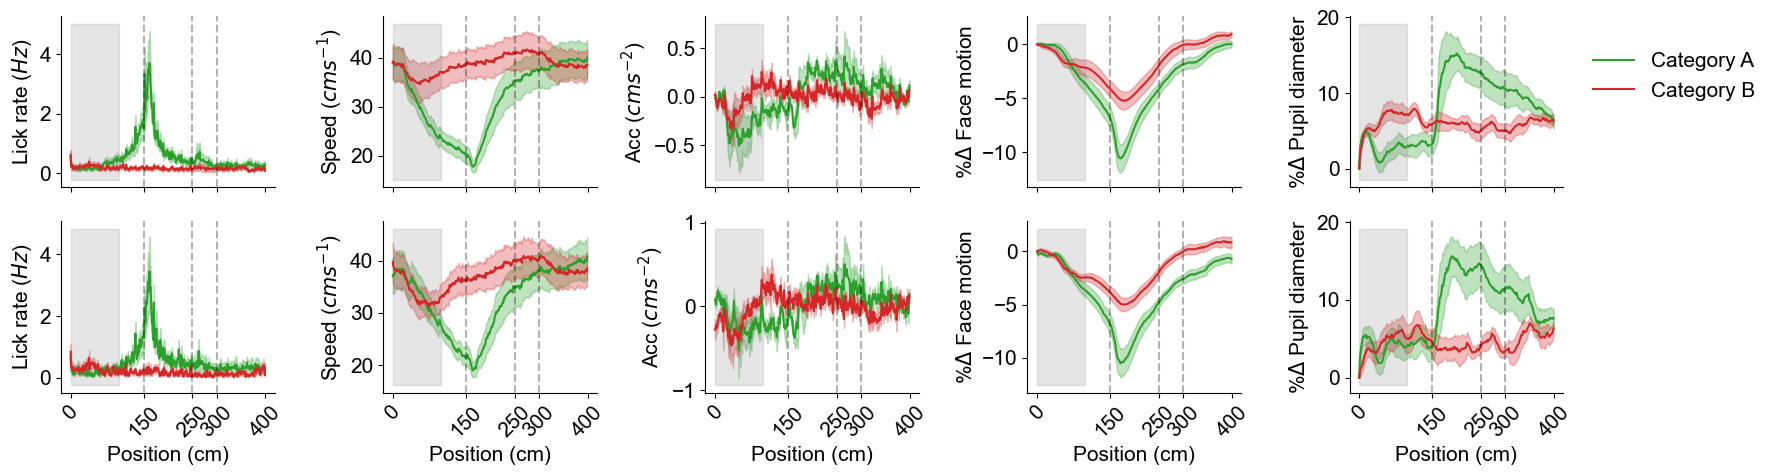

In [35]:
labels = [r"Lick rate ($Hz$)", r"Speed ($cms^{-1}$)", r"Acc ($cm s^{-2}$)", r"%$\Delta$ Face motion", r"%$\Delta$ Pupil diameter"]
fig, ax = plt.subplots(2, len(features), figsize=(18, 5), sharex=True)
for i_f in range(len(features)):
    if i_f == len(features)-1:
        legend = True
    else:
        legend = False
    plot_catvsbehav(vstacked_matched[:,i_f, 0], vstacked_matched[:,i_f, 1], labels[i_f], True, ax[1, i_f], legend=False)
    plot_catvsbehav(vstacked_nonmatched[:,i_f, 0], vstacked_nonmatched[:,i_f, 1], labels[i_f], False, ax[0, i_f],  legend=legend)
plt.tight_layout()